In [90]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [91]:
# !pip install wandb

In [92]:
# !wandb login

In [93]:
import wandb

In [94]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Current Device:", torch.cuda.current_device())
else:
    print("GPU not detected")

CUDA available: True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
Current Device: 0


In [95]:
train_df= pd.read_csv("../data/train.csv")
test_df= pd.read_csv("../data/test.csv")

In [96]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [97]:
train_df.iloc[2,1]

'Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.'

## EDA

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
# ********************** basic statistics ****************
print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print(f"\nMissing values in training dataset:\n{train_df.isna().sum()}")
print(f"\nMissing values in testing dataset:\n{test_df.isna().sum()}")


# ******************** ANSWER DISTRIBUTION *******************
# Very important for understanding bias
train_answer_dist= train_df['answer'].value_counts()
print(f"\nTraining Dataset Answer Distribution:")
print(train_answer_dist)
print(f"\nPercentages:\n{round(train_answer_dist/len(train_df)*100,1)}")


Train dataset shape: (2000, 8)
Test dataset shape: (500, 7)

Missing values in training dataset:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Missing values in testing dataset:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

Training Dataset Answer Distribution:
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

Percentages:
answer
B    24.5
C    23.0
A    18.4
D    17.9
E    16.2
Name: count, dtype: float64


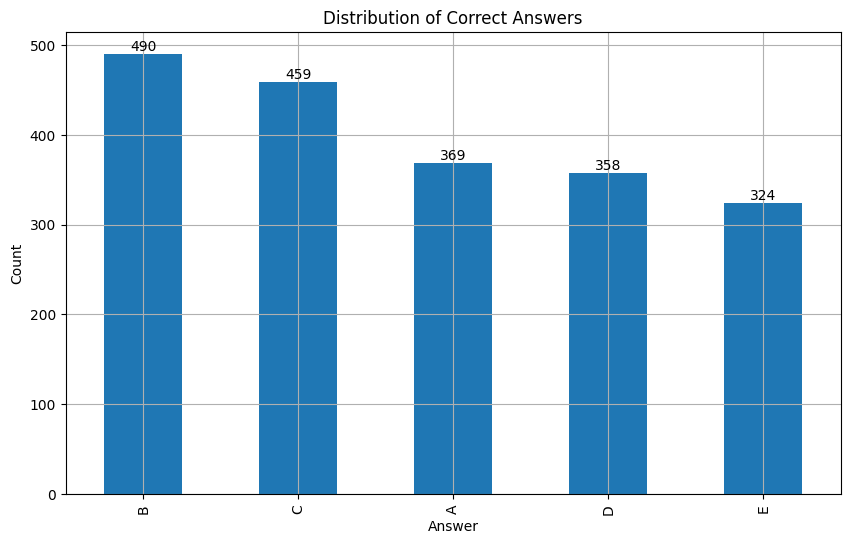

In [100]:
#******************** Plot Answer distribution *************
plt.figure(figsize=(10, 6))
ax= train_answer_dist.plot(kind= 'bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.title('Distribution of Correct Answers')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.grid(True)
plt.show()

In [101]:
# ************************** Text Length Analysis *********************
# Understanding question and option lengths
train_df['prompt_length']= train_df['prompt'].str.len()
train_df['option_A_len']= train_df['A'].str.len()
train_df['option_B_len']= train_df['B'].str.len()
train_df['option_C_len']= train_df['C'].str.len()
train_df['option_D_len']= train_df['D'].str.len()
train_df['option_E_len']= train_df['E'].str.len()

print(f"\nText Length Statistic:")
print(f"\n{train_df[['prompt_length', 'option_A_len', 'option_B_len', 'option_C_len', 'option_D_len', 'option_E_len']].describe()}")


Text Length Statistic:

       prompt_length  option_A_len  option_B_len  option_C_len  option_D_len  \
count    2000.000000   2000.000000   2000.000000   2000.000000    2000.00000   
mean      117.669500    164.091500    166.616500    167.227000     162.56350   
std        44.408674    105.677145    113.829917    105.723674     104.11657   
min        19.000000      1.000000      2.000000      2.000000       1.00000   
25%        87.750000     86.000000     82.000000     88.000000      91.00000   
50%       111.000000    143.000000    151.000000    158.000000     141.00000   
75%       141.000000    234.000000    222.000000    224.000000     231.00000   
max       337.000000    472.000000    662.000000    530.000000     450.00000   

       option_E_len  
count   2000.000000  
mean     164.230000  
std      107.777712  
min        2.000000  
25%       84.000000  
50%      144.000000  
75%      224.000000  
max      587.000000  


In [102]:
#************************* Question Patterns ***************************
# are there common question prefixs?
prefixs= train_df['prompt'].str[:50].value_counts().head(10)
print(f"Common questions prefixes:\n {prefixs}")

# *********************** Option Similarity **************************
# Check if options are very similar

def cal_similarity(row):
    options= [row['A'],row['B'], row['C'], row['D'], row['E']]
    prefixes= [ops[:30] for ops in options]
    return len(set(prefixes))

train_df['unique_prefixe_options']= train_df.apply(cal_similarity, axis=1)

print(f"\nQuestions with very similar options (unique_prefixs <3):")
print(f"{(train_df['unique_prefixe_options']<3).sum()}")

Common questions prefixes:
 prompt
Identify the correct statement: What is the relati    22
Choose the correct answer: Which of the following     21
Pick the best possible answer: What is the reason     19
Identify the correct statement: What is the signif    18
Pick the best possible answer: What is the relatio    18
Determine the correct option: What is the relation    18
Select the most accurate option: What is the reaso    18
Which of the following is correct? What is the rel    17
Select the most accurate option: What is the relat    17
Which of the following is correct? What is the rea    16
Name: count, dtype: int64

Questions with very similar options (unique_prefixs <3):
1078


### 1078 out of 2000 (54%) have very similar option prefixes ; Means
* Simple keyword matching will FAIL 
* Need semantic understanding, not just text overlap \n
* This is why pretrained transformers (Model 2) will shine \n

In [103]:
# ******************************** Correct answer position ***********************
# Is correct answer more likely in longer/shorter options?

for ans in ["A", "B", "C", "D", "E"]:
    subset= train_df[train_df['answer']==ans]
    ans_desc_stat= subset[f"option_{ans}_len"].describe()
    print(f"\nStatistic for correct option {ans}:\n{ans_desc_stat}")



Statistic for correct option A:
count    369.000000
mean     181.363144
std      104.731143
min        3.000000
25%      112.000000
50%      191.000000
75%      240.000000
max      409.000000
Name: option_A_len, dtype: float64

Statistic for correct option B:
count    490.000000
mean     171.183673
std      126.513863
min        2.000000
25%       77.000000
50%      144.000000
75%      251.000000
max      545.000000
Name: option_B_len, dtype: float64

Statistic for correct option C:
count    459.000000
mean     182.346405
std       99.116643
min        9.000000
25%      104.000000
50%      189.000000
75%      254.000000
max      395.000000
Name: option_C_len, dtype: float64

Statistic for correct option D:
count    358.000000
mean     180.349162
std       78.417066
min       24.000000
25%      118.250000
50%      183.000000
75%      235.000000
max      403.000000
Name: option_D_len, dtype: float64

Statistic for correct option E:
count    324.000000
mean     199.669753
std      136.51

Key Questions to Answer:

1. Is there answer bias? (Are B and C more common than E?) -> yes (they are 50%)
2. Are correct answers longer/shorter than incorrect ones?
3. Do questions follow patterns? (e.g., "Pick the best possible answer:") -> yes
4. How similar are the options? (Will text matching work or need deep understanding?)

## Data Preprocessing

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow import keras

In [105]:
# ********************* investigate duplicates ****************
# 1. Find exact duplicates (question/prompt + all options same)

duplicate_mask= train_df[['prompt', "A", "B", "C", 'D', 'E']].duplicated(keep=False) # keep=False ; do NOT keep any copy special If a duplicate group exists: mark ALL members True.
duplicates_df= train_df[duplicate_mask]

print(f"Total rows involved in duplicates: {len(duplicates_df)}")

# 2. Check if duplicates have SAME or DIFFERENT answers
duplicate_groups= train_df[duplicate_mask].groupby(['prompt', "A", "B", "C", 'D', 'E']) # this groupby return groupby object ; like list of two things first that unique (prompt, a, b, c, d, e) select cols (called as 'name') and 'group' dataframe where exact those rows come which have these same selected columns(prompt, 'a'...)

print("\n*** Critical: Do duplicates agree on answer? ****")

for name, group in list(duplicate_groups): 
    print(f"\nQuestion: {name[0][:80]}..")
    print(f"Appears {len(group)} times")
    print(f"Answers: {group['answer'].values}")

    if group['answer'].nunique()>1:
        print("Warning: Same question and options but different answer!")

# 3. find same prompts with different options
prompt_duplicates= train_df[train_df['prompt'].duplicated(keep=False)]
prompt_group= prompt_duplicates.groupby('prompt')

print(f"Total rows involved in prompt duplicates: {len(prompt_duplicates)}")

for prompt, group in list(prompt_group):
    if len(group[['A', "B", "C", "D", "E"]].drop_duplicates())>1:
        print(f"\nPrompt: {prompt[:80]}...")
        print(f"Appears with {len(group)} different option sets")
        # print(group[['A', "B", "C", "D", "E", "answer"]])


Total rows involved in duplicates: 344

*** Critical: Do duplicates agree on answer? ****

Question: Choose the correct answer: What are permutation-inversion groups?..
Appears 3 times
Answers: ['E' 'E' 'E']

Question: Choose the correct answer: What are permutation-inversion groups? based on the g..
Appears 2 times
Answers: ['E' 'E']

Question: Choose the correct answer: What are the four qualitative levels of crystallinity..
Appears 3 times
Answers: ['B' 'B' 'B']

Question: Choose the correct answer: What is Lorentz symmetry or Lorentz invariance in rel..
Appears 2 times
Answers: ['E' 'E']

Question: Choose the correct answer: What is a pycnometer?..
Appears 2 times
Answers: ['D' 'D']

Question: Choose the correct answer: What is magnetic susceptibility? based on the given c..
Appears 2 times
Answers: ['B' 'B']

Question: Choose the correct answer: What is the American Petroleum Institute (API) gravit..
Appears 2 times
Answers: ['A' 'A']

Question: Choose the correct answer: What is 

In [106]:
# train_df.drop_duplicates(subset=['prompt', "A", "B", "C", 'D', 'E'], inplace=True)

In [107]:
# train_df['answer'].value_counts().plot(kind='bar')
# plt.title("Label Distribution after dropping duplicate rows!")
# plt.xlabel("Answer options")
# plt.xlabel("Frequency")

# plt.show()

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

def clean_prompt(prompt):
    # remove standardized prefixes
    if (':' in prompt) or ('?' in prompt):
        if ':' in prompt:
            sep_prompt= prompt.strip().split(':')
            return ':'.join(sep_prompt[1:]).strip()
        if '?' in prompt and prompt.index('?')!= len(prompt.strip())-1:
            sep_prompt= prompt.strip().split('?')
            return '?'.join(sep_prompt[1:]).strip()
    return prompt.strip()

# Reduces noise in TF-IDF features
# Shorter sequences for BERT (fits more context in 512 tokens)
# Models focus on actual question content

train_df['prompt']= train_df['prompt'].apply(clean_prompt)
test_df['prompt']= test_df['prompt'].apply(clean_prompt)

# ************************* Train/Validate split *********************
# train_data, val_data= train_test_split(train_df, test_size= 0.2, random_state=42, stratify= train_df['answer']) # keep answer distribution
train_df['prompt_group']= train_df['prompt'].factorize()[0]
splitter= GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in splitter.split(train_df, groups= train_df['prompt_group']):
    train_data= train_df.iloc[train_idx].reset_index(drop=True)
    val_data= train_df.iloc[val_idx].reset_index(drop=True)
    break # only one split

# verify no leakage
train_prompts= set(train_data['prompt'].unique())
val_prompts= set(val_data['prompt'].unique())
overlap= train_prompts & val_prompts
print(f"Overlapping prompts: {len(overlap)} (should be 0!)")



print(f"Train: {len(train_data)}, validation: {len(val_data)}")


# def clean_text(text):
#     # Usually not needed for modern models, but consider:
#     text = text.strip()
#     # Don't lowercase if using pretrained models (they expect proper case)
#     return text

# ***************************** Label Encoder ***********************
label_map= {"A":0, "B":1, "C":2, "D":3, "E":4}
train_data['label']= train_data['answer'].map(label_map)
val_data['label']= val_data['answer'].map(label_map)


# # **************************** combine question and options *******************
# Combine question + all options into one text

def ceate_text_feature(row):
    return f"{row['prompt']} [SEP] A: {row['A']}, B: {row['B']}, C: {row['C']}, D: {row['D']}, E: {row['E']}"

train_data['combined_text']= train_data.apply(ceate_text_feature, axis=1)
val_data['combined_text']= val_data.apply(ceate_text_feature, axis=1)
test_df['combined_text']= test_df.apply(ceate_text_feature, axis=1)

Overlapping prompts: 0 (should be 0!)
Train: 1572, validation: 428


In [109]:
# # ****************************** if we want to do cross validation (n_splits>1) *********************************
# train_df['prompt_group']= train_df['prompt'].factorize()[0]

# ## ************** K-fold validation **************************
# n_splits=3
# splitter= GroupShuffleSplit(n_splits=n_splits,test_size=0.2, random_state=42)

# for fold, (train_idx, val_idx) in enumerate(splitter.split(train_df, groups= train_df['prompt_group']),1):
#     print(f"{'='*50}")
#     print(f"FOLD {fold}/{n_splits}")
#     print(f"{'='*50}")

#     train_data= train_df.iloc[train_idx].reset_index(drop=True)
#     val_data= train_df.iloc[val_idx].reset_index(drop=True)

#     print(f"Train : {len(train_data)} samples")
#     print(f"Val: {len(val_data)} samples")

#     # verify leakage
#     overlap= set(train_data['prompt']) & set(val_data['prompt'])
#     assert len(overlap)==0, f"Leakage detected! {len(overlap)} overlapping prompts"


#     # ***************************** Label Encoder ***********************
#     label_map= {"A":0, "B":1, "C":2, "D":3, "E":4}
#     train_data['label']= train_data['answer'].map(label_map)
#     val_data['label']= val_data['answer'].map(label_map)

#     # **************************** combine question and options *******************
#     # Combine question + all options into one text
#     train_data['combined_text']= train_data.apply(ceate_text_feature, axis=1)
#     val_data['combined_text']= val_data.apply(ceate_text_feature, axis=1)


#     #************************* Train Model1 *********************
    
    
    


In [110]:
############### weight and bais initiaze for first model ##############
# Start a new wandb run to track this script.
run_1 = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="24f2002970-indian-institute-of-technology-madras",
    # Set the wandb project where this run will be logged.
    project="24F2002970-t22026",
    # Track hyperparameters and run metadata.
    name="Base Model",
    config={
        "architecture": "Tf-idf+ANN",
        "epochs": 1,
        "batch_size": 32,
        "max_features":5000,
        "ngram_range":(1,2),
        "number_of_levels":4
    },
)

MAP@3,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█████████████████
batch/accuracy,▁███████████████████████████████████████
batch/batch_step,▁▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▆▆▇▁▁▁▂▂▃▃▃▃▄▄▅▅▅▅▆▆▆▇█
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/epoch,▁▁▂▃▃▄▅▅▅▅▆▆▆▆▇▇█▁▁▁▁▂▂▂▂▃▃▃▄▄▅▅▆▆▆▇▇▇▇█
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+1,...


In [111]:
# **************************** Feature extraction ************************************** 
# convert text to tf-idf vectors
vectorizer= TfidfVectorizer(
    max_features=5000, # limited vocabulary
    ngram_range=(1,2), # unigram and bigram
    min_df= 2 # ignore rare words
    
)

X_train= vectorizer.fit_transform(train_data['combined_text'])
X_val= vectorizer.transform(val_data['combined_text'])
y_train= train_data['label'].values
y_val= val_data['label'].values

X_test= vectorizer.transform(test_df['combined_text'])

print(f"Feature Shape: {X_train.shape}")



Feature Shape: (1572, 5000)


## Model Building

In [112]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

In [113]:
# ************************ Model1 (Tf-IDF + ANN) **********************

model= Sequential([
    Input(shape= (X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax') # classes: A, B, C, D, E    
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,797 (5.01 MB)

 Trainable params: 1,313,797 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [114]:
from wandb.integration.keras import WandbMetricsLogger
from tensorflow.keras.callbacks import Callback

class MAPCallback(Callback):
    def on_epoch_end(self, epoch, logs = None):
        pred= self.model.predict(X_val)

        decode_label= {0:'A', 1:'B', 2:'C', 3:'D', 4:'E'}

        top3_predictions =[]

        for p in pred:
            top3_idx= np.argsort(p)[::-1][:3]
            top3= [decode_label[idx] for idx in top3_idx]

            top3_predictions.append(top3)
        map3= calculate_map(top3_predictions, pd.Series(y_val).map(decode_label).tolist())

        wandb.log({"MAP@3": map3})


## Training

In [115]:
def calculate_map(predictions, ground_truth):
    """
    predictions would be [["A", "B", "D"],..] like this and 
    ground_truth would be ["A", "B", ...]
    """
    scores=[]
    for preds, truth in zip(predictions, ground_truth):
        if truth in preds:
            position= preds.index(truth)+ 1 # 1-indexed
            scores.append(1.0/position)
        else:
            scores.append(0.0)

    return np.mean(scores)

In [116]:
history= model.fit(
    X_train.toarray(), # convert sparse to dense
    y_train,
    validation_data=(X_val.toarray(),y_val ),
    epochs=45,
    batch_size=32,
    callbacks=[WandbMetricsLogger(log_freq='batch'), MAPCallback()],
    verbose=1,
)

Epoch 1/45
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4197 - loss: 1.519
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6330 - loss: 1.3361 - val_accuracy: 0.9229 - val_loss: 0.7163
Epoch 2/45
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9858 - loss: 0.306
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9917 - loss: 0.1697 - val_accuracy: 1.0000 - val_loss: 0.0380
Epoch 3/45
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.013
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0078
Epoch 4/45
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.004
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 5/45
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.003
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch

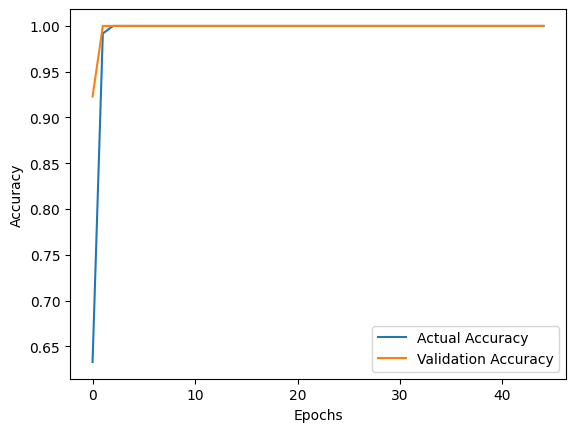

In [117]:
plt.plot(history.history['accuracy'], label='Actual Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel("Accuracy")

plt.legend()
plt.show()

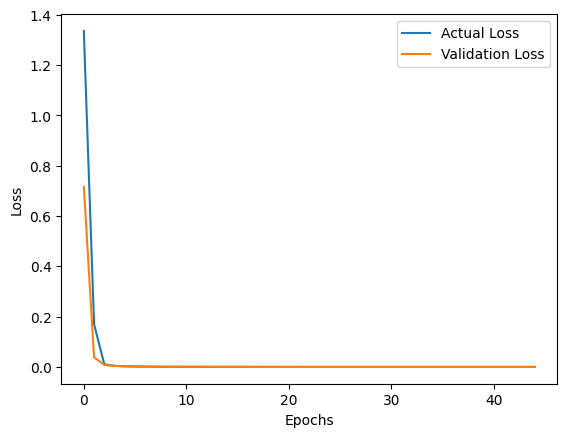

In [118]:
plt.plot(history.history['loss'], label="Actual Loss")
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel("Loss")

plt.legend()
plt.show()

## First Model Inferance

In [119]:
# ******************** inference for first model ******************
def predict_top3(model, X):
    # Get probabilities for all 5 classes
    probs= model.predict(X)
    # Get top 3 indices for each sample
    top3_indices= np.argsort(probs, axis=1)[:, -3:][:,::-1]

    # Convert back to A, B, C, D, E
    reverse_map_level= {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}
    predictions=[]
    for indics in top3_indices:
        predictions.append([reverse_map_level[i] for i in indics])
    return predictions

## Evaluation

In [120]:
# ***** prediction on validation data and evaluation ****
# by model1
pred_top3_val_data= predict_top3(model, X_val)

model1_eval_score_on_val= calculate_map(pred_top3_val_data,val_data['answer'].tolist())

print(f"@map for first model:{model1_eval_score_on_val}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
@map for first model:1.0


In [121]:
run_1.log({
    "@map_on_val":model1_eval_score_on_val
})

run_1.finish()

@map_on_val,▁
MAP@3,▁███████████████████████████████████████
batch/accuracy,▁███████████████████████████████████████
batch/batch_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▇▅▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁███████████████████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


## Model 2 (Transfer Learning Strategies) 
* Treat each option separately as a classification task

In [122]:
############### weight and bais initiaze for second model ##############
# Start a new wandb run to track this script.
run_2 = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="24f2002970-indian-institute-of-technology-madras",
    # Set the wandb project where this run will be logged.
    project="24F2002970-t22026",
    # Track hyperparameters and run metadata.
    name="Model2-Transfer Learning Strategy",
    config={
        "architecture": "distilbert",
        "epochs": 1,
        "batch_size": 16,
        "number of levels":2
    },
)

In [123]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset

# ******************** Choose pretrain model ****************
# Options (ranked by quality vs speed):
# 1. "distilbert-base-uncased" - FASTEST, good enough 
# 2. "bert-base-uncased" - BALANCED
# 3. "roberta-base" - BEST QUALITY, slower
# 4. "microsoft/deberta-base" - CUTTING EDGE (if GPU available)

model_name= "distilbert-base-uncased"
# model_name= "microsoft/deberta-base"

tokenizer= AutoTokenizer.from_pretrained(model_name)

print(f"Tokenizer loaded : {model_name}")
print(f"Vocab size : {tokenizer.vocab_size}")

# *********** step2: format data for bert ******************

def format_question_option(question, option):
    """
    fomat would be : [CLS] question [SEP] option [SEP]
    This helps BERT understand: question is premise, option is hypothesis
    """
    return f"{question} [SEP] {option}"

X_data=[]
y_data=[]

for _, row in train_data.iterrows():
    clear_ques= row['prompt'] # Already clear

    for option_letter in ['A', 'B', 'C', 'D', 'E']:
        option_text= row[option_letter]
        formatted= format_question_option(clear_ques,option_text)
        X_data.append(formatted)

        # Label: 1 if this option is correct, 0 otherwise
        label= 1 if row['answer']== option_letter else 0
        y_data.append(label)
print(f"Training egs created: {len(X_data)}")
# 1576(train size after splite) questions × 5 options = 10,000 training examples!

# ============ STEP 3: TOKENIZE ============
# BERT works with token IDs, not raw text

train_encodings= tokenizer(
    X_data, 
    truncation=True,
    padding= True,
    max_length=512, # max len of question + option
    return_tensors='pt', # pytorch tensors
)


print(f"Input Ids shape: {train_encodings['input_ids'].shape}")
print(f"Attension masked shape: {train_encodings['attention_mask'].shape}")

# convert label to tensor

y_data_tensor= torch.tensor(y_data)

# *************** step4: create dataset *********

class MCQDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings= encodings
        self.labels= labels

    def __getitem__(self, idx):
        item={
            "input_ids": self.encodings['input_ids'][idx],
            "attention_mask":self.encodings['attention_mask'][idx]
        }
        item['labels']= self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)
        

train_dataset= MCQDataset(train_encodings, y_data_tensor)
train_loader= DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Data loader created with batch size 16")



/home/aditya29f70/smart_mcq_solver_challenge_iitm_dl_genai_proj/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer loaded : distilbert-base-uncased
Vocab size : 30522
Training egs created: 7860
Input Ids shape: torch.Size([7860, 194])
Attension masked shape: torch.Size([7860, 194])
Data loader created with batch size 16


In [ ]:
# ******************** step 5: load pretrained bert ******************
model_1= AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2, # binary: correct 1 or incorrect 0
)

# Get the underlying transformer model
base_model = model_1.base_model

# # Freeze all except last 2 layers
# for param in base_model.encoder.layer[:-2].parameters():
#     param.requires_grad = False

# Freeze first 4 layers (DistilBERT has 6 layers total)
for param in base_model.transformer.layer[:-2].parameters():
    param.requires_grad = False


device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_1.to(device)
print(f"\nModel loaded on device: {device}")


# **************** step6: fine-tune on our data ***************
from torch.optim import AdamW
optimizer= AdamW(model_1.parameters(), lr=2e-5) # transfer learning LR

num_epochs=50
model_1.train()
print(f"\nStarting fine-tuning for {num_epochs} epochs...\n")

for epoch in range(num_epochs):
    total_loss=0

    for batch_idx, batch in enumerate(train_loader):
        # Move batch to device
        input_ids= batch['input_ids'].to(device)
        attention_mask= batch['attention_mask'].to(device)
        labels= batch['labels'].to(device)

        # forward pass
        output= model_1(
            input_ids= input_ids,
            attention_mask= attention_mask,
            labels= labels
        )
        loss= output.loss

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+= loss.item()
        wandb.log({
            "batch_idx": batch_idx+ 1,
            "batch_loss":loss.item()
        })

        if (batch_idx+1)% 50==0:
            print(f"Epoch: {epoch+1}, Batch: {batch_idx}/{len(train_loader)}, Loss: {loss.item():0.4f}")
    avg_loss= total_loss/len(train_loader)
    wandb.log({
        "epoch": epoch+1,
        "avg_loss":avg_loss
    })
    print(f"Epoch: {epoch+1}, Average Loss: {avg_loss}")

print("Fine-tune completed!")
        
            


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 608.84it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded on device: cuda

Starting fine-tuning for 50 epochs...

Epoch: 1, Batch: 49/492, Loss: 0.7646
Epoch: 1, Batch: 99/492, Loss: 0.5773
Epoch: 1, Batch: 149/492, Loss: 0.3058
Epoch: 1, Batch: 199/492, Loss: 0.5822
Epoch: 1, Batch: 249/492, Loss: 0.5619
Epoch: 1, Batch: 299/492, Loss: 0.7745
Epoch: 1, Batch: 349/492, Loss: 0.4456
Epoch: 1, Batch: 399/492, Loss: 0.4287
Epoch: 1, Batch: 449/492, Loss: 0.6185
Epoch: 1, Average Loss: 0.5008361198734946
Epoch: 2, Batch: 49/492, Loss: 0.3354
Epoch: 2, Batch: 99/492, Loss: 0.5390
Epoch: 2, Batch: 149/492, Loss: 0.5267
Epoch: 2, Batch: 199/492, Loss: 0.4243
Epoch: 2, Batch: 249/492, Loss: 0.4566
Epoch: 2, Batch: 299/492, Loss: 0.4119
Epoch: 2, Batch: 349/492, Loss: 0.3595
Epoch: 2, Batch: 399/492, Loss: 0.3158
Epoch: 2, Batch: 449/492, Loss: 0.2872
Epoch: 2, Average Loss: 0.36736226042475156
Epoch: 3, Batch: 49/492, Loss: 0.1830
Epoch: 3, Batch: 99/492, Loss: 0.1848
Epoch: 3, Batch: 149/492, Loss: 0.3057
Epoch: 3, Batch: 199/492, Loss

In [ ]:
print(model_1)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
# ******************* step7 : prediction on validate ****************

def predict_with_bert_model2(model, val_data, tokenizer, device):
    """
    For each question, get scores for all 5 options
    Rank them to get top 3
    """
    model.eval()
    predictions=[]

    with torch.no_grad():
        prop=[]
        for _, row in val_data.iterrows():
            clear_q= row['prompt']

            # get score for all 5 options
            option_scores={}

            each_row_prob=[]
            for option in ['A', 'B', 'C', 'D', 'E']:
                option_text= row[option]
                formatted= format_question_option(clear_q, option_text)

                # Tokenize
                encoding = tokenizer(
                    formatted,
                    truncation=True,
                    padding=True,
                    max_length=512,
                    return_tensors='pt'
                )
                
                # Move to device
                input_ids= encoding['input_ids'].to(device)
                attention_mask= encoding['attention_mask'].to(device)

                # get logists
                outputs= model(input_ids=input_ids, attention_mask= attention_mask)
                logits= outputs.logits[0]

                # score= probability of being correct
                score= torch.softmax(logits, dim=0)[1].item() # class 1 = correct probability
                option_scores[option]= score
                each_row_prob.append(score)

            prop.append(each_row_prob)
            # sort by score, get top 3
            top3= sorted(option_scores.items(), key= lambda x: x[1], reverse=True)[:3]
            top3_letters= [letter for letter, score in top3]
            predictions.append(top3_letters)
    return predictions,prop
            
# Predict on validation
# print("Generating predictions on validation set...")

# val_predictions_model2= predict_with_bert_model2(
#     model_1, val_data, tokenizer, device
# )           
                
                

## Inferance model2

In [ ]:
# ******************** inference for second model ******************
def predict_top3_2(model, val_data, tokenizer, device):
    top3_list,_= predict_with_bert_model2(model, val_data, tokenizer, device)
    top3= [" ".join(top3) for top3 in top3_list]
    return top3

In [ ]:
pred_test_top3= predict_top3_2(model_1, test_df,tokenizer, device)

## Evaluation Model2

In [ ]:
# by model2
pred_top3_val_data_sec_model= predict_top3_2(model_1, val_data,tokenizer, device)
model2_eval_on_val= calculate_map(pred_top3_val_data_sec_model,val_data['answer'].tolist())
print(f"@map for second model: {model2_eval_on_val}")

run_2.log({
    "@map_on_val":model2_eval_on_val
})

run_2.finish()

@map for second model: 1.0


@map_on_val,▁
@map_on_val,1


## DLGenAI Project Milestone-2

1. Load train.csv using the Hugging Face datasets library (do not use pandas). Use the .map() function to create a new column called combined_text that concatenates the prompt and A columns with a space in between. E.g., prompt_text A_text. What is the exact character length (total number of string characters using Python's len() function, NOT the number of tokens) of the combined_text string for the row at index 51? Note: We follow zero-indexing here.

In [ ]:
from datasets import load_dataset

# step 1: load train.csv using huggingface  datasets (not pandas)

dataset= load_dataset('csv', data_files="../data/train.csv", split='train')

# step 2: use .map() to create the combined_text column
def combine_text(example):
    return {"combine_text":example["prompt"]+ " " + example["A"]}

dataset= dataset.map(combine_text)

# step3 get the character length at index 51 (zero-indexed)
length= len(dataset[51]["combine_text"])

print(length)


614


Load the bert-base-uncased model using AutoModel.from_pretrained(). Tokenize the prompt from row ID 0 using the tokenizer's default settings (do not apply any manual padding or truncation). Pass this tokenized input through the model. Look at the output object. 

What is the exact shape of the last_hidden_state tensor returned? 

Note: We follow zero-indexing here.

In [ ]:
from transformers import BertTokenizer, AutoModel

tokenizer= BertTokenizer.from_pretrained("bert-base-uncased")
model= AutoModel.from_pretrained("bert-base-uncased")

# Tokenize only row 0's prompt - default settings (no padding/truncation)
input= tokenizer(dataset['prompt'][0], return_tensors='pt')

# forward pass
import torch
with torch.no_grad():
    output= model(**input)

print(output.last_hidden_state.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3588.70it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([1, 31, 768])


In [ ]:
cls_vector = output.last_hidden_state[0][0]  # [CLS] token embedding
first_5 = cls_vector[:5]
result = first_5.sum().item()
print(round(result, 4))

-1.2001


Load bert-base-uncased with the parameter output_attentions=True. Tokenize the exact string "Light-ion fusion is a technique." (ensuring you set return_tensors='pt') and pass it through the model. Extract the attention matrix for the last layer (index -1) and the first attention head (head index 0). 

What is the exact attention weight (a float value) that the [CLS] token (token index 0) pays to the word fusion (you will need to find the specific token index for fusion in the input_ids)? (Round your answer to 4 decimal places).  

*


In [ ]:


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True)

# Tokenize the exact string
inputs = tokenizer("Light-ion fusion is a technique.", return_tensors="pt")

# Check token positions
print(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))

# Forward pass
with torch.no_grad():
    output = model(**inputs)

# Find index of "fusion" token
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
fusion_idx = tokens.index("fusion")
print(f"'fusion' is at index: {fusion_idx}")

# Extract: last layer (-1), first head (0), [CLS] (row 0), attention to fusion
attn_weight = output.attentions[-1][0][0][0][fusion_idx].item()
print(round(attn_weight, 4))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3205.51it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


['[CLS]', 'light', '-', 'ion', 'fusion', 'is', 'a', 'technique', '.', '[SEP]']
'fusion' is at index: 4
0.1025


Context-Aware Embeddings 

Initialize the sentence-transformers/all-MiniLM-L6-v2 model. Use the model's .encode() method to generate embeddings for both the prompt and Option B for row ID 0. Calculate the cosine similarity between these two vectors specifically using the sentence_transformers.util.cos_sim() function. What is the resulting similarity score rounded to 4 decimal places? Note: We follow zero-indexing here.

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Initialize model
model= SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# get prompt and option b for row 0
prompt_text= dataset['prompt'][0]
option_b= dataset['B'][0]

print(f"Prompt: {prompt_text}")
print(f"Option B: {option_b}")

# Generate embeddings
prompt_embedding = model.encode(prompt_text)
option_b_embedding = model.encode(option_b)

# Cosine similarity using sentence_transformers util
similarity = util.cos_sim(prompt_embedding, option_b_embedding)

print(round(similarity.item(), 4))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3804.91it/s]


Prompt: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Option B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
0.7658


Build two complete ranking pipelines evaluating every row in train.csv.

Pipeline 1: Use the TF-IDF cosine similarity approach from Milestone 1.

Pipeline 2: Use the sentence-transformers/all-MiniLM-L6-v2 model to generate embeddings for the prompt and all five options. Rank options using cosine similarity to form Top-3 predictions.

First, what is the final MAP@3 score of the all-MiniLM-L6-v2 pipeline across the entire training set? 

Second, count the number of questions for which the correct answer is NOT present in the TF-IDF Top-3 predictions BUT IS present in the MiniLM Top-3 predictions. What is this exact resulting count?  

In [ ]:
df = dataset.to_pandas()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

options= ['A', 'B', 'C', 'D', 'E']


tfidf_preds=[]
for _, row in df.iterrows():
    prompt= row['prompt']

    options_text= [row[option] for option in options]

    corpus= [prompt]+ options_text

    tfidf= TfidfVectorizer().fit_transform(corpus)

    similarities= cosine_similarity(tfidf[:1], tfidf[1:]).flatten()
    ranked= [options[i] for i in  np.argsort(similarities)[-3:][::-1]]
    tfidf_preds.append(ranked)

labels = df["answer"].tolist()
tfidf_map = calculate_map(tfidf_preds, labels)
print(f"TF-IDF MAP@3: {tfidf_map:.4f}")

minilm_preds=[]
for _, row in df.iterrows():
    prompt= row['prompt']
    options_text= [row[option] for option in options]

    prompt_emb= model.encode(prompt, convert_to_tensor=True)
    option_embs = model.encode(options, convert_to_tensor=True)

    sims = util.cos_sim(prompt_emb, option_embs).squeeze().cpu().numpy()
    ranked = [options[i] for i in np.argsort(sims)[-3:][::-1]]
    minilm_preds.append(ranked[:3])

minilm_map = calculate_map(minilm_preds, labels)
print(f"MiniLM MAP@3: {minilm_map:.4f}")



for (tfidf_top3, minilm_top3, label) in zip(tfidf_preds, minilm_preds, labels):
    count=0
    if (label not in tfidf_top3) and (label in minilm_top3):
        count+=1
print(f"Questions where MiniLM recovers what TF-IDF missed: {count}")

TF-IDF MAP@3: 0.3269
MiniLM MAP@3: 0.3957
Questions where MiniLM recovers what TF-IDF missed: 0


Zero-shot classification concepts 

Initialize the Hugging Face pipeline for "zero-shot-classification" (it will default to facebook/bart-large-mnli). For the prompt of the 2nd row (index 1), pass Options A, B, and C as the candidate_labels. What is the probability score given to the top-ranked option? (Round to 4 decimal places).

In [ ]:
from transformers import pipeline
# Get prompt and options A, B, C for row index 1
prompt = dataset["prompt"][1]
candidate_labels = [dataset["A"][1], dataset["B"][1], dataset["C"][1]]

print(f"Prompt: {prompt}")
print(f"Candidates: {candidate_labels}")

# Initialize zero-shot-classification pipeline (defaults to facebook/bart-large-mnli)
classifier = pipeline("zero-shot-classification")

# Run classification
result = classifier(prompt, candidate_labels=candidate_labels)

print(result)

# Top-ranked option score (scores are already sorted descending)
top_score = result["scores"][0]
print(f"Top label: {result['labels'][0]}")
print(f"Top score: {round(top_score, 4)}")

sum_of_top_score= sum(result['scores'])
print("Sum of top 3 scores",sum_of_top_score)

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


Prompt: What is accelerator-based light-ion fusion?
Candidates: ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion

Loading weights: 100%|██████████| 515/515 [00:00<00:00, 3692.39it/s]


{'sequence': 'What is accelerator-based light-ion fusion?', 'labels': ['Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.', 'Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion

Run the exact same zero-shot classification as the previous question, but this time pass the argument multi_label=True. 

What is the absolute difference between the sum of the 3 probabilities in the previous question (which uses Softmax) and the sum of the 3 probabilities in this question (which uses independent Sigmoids)?

In [ ]:
# ── Multi-label (Sigmoid) — this question ─────────────────────────────────────
result_sigmoid = classifier(prompt, candidate_labels=candidate_labels, multi_label=True)
sigmoid_sum = sum(result_sigmoid["scores"])
print(f"Sigmoid scores: {result_sigmoid['scores']}")
print(f"Sigmoid sum:    {round(sigmoid_sum, 4)}")

# ── Absolute difference ───────────────────────────────────────────────────────
abs_diff = abs(sum_of_top_score - sigmoid_sum)
print(f"Absolute difference: {round(abs_diff, 4)}")

Sigmoid scores: [0.0004692664369940758, 2.063553074549418e-05, 1.970029916265048e-05]
Sigmoid sum:    0.0005
Absolute difference: 0.9995


Let's try Generative AI instead of Classification. 

Load a Small Language Model like google/flan-t5-small using the Hugging Face pipeline("text2text-generation"). Construct the following exact string for row index 0: "Question: [prompt]. Is the correct answer A: [A] or B: [B]? Answer with just the letter A or B." 
Pass this string to the pipeline, setting max_new_tokens=5. What is the exact string output returned by the model? 

In [ ]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-small")
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-small")

#  Exact string format as specified in the question
constructed_text = f"Question: {dataset['prompt'][0]}. Is the correct answer A: {dataset['A'][0]} or B: {dataset['B'][0]}? Answer with just the letter A or B."

print(constructed_text)  # verify the exact string

inputs = tokenizer(constructed_text, return_tensors="pt")
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=5)

result = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(result)  #  this is your exact answer

Loading weights: 100%|██████████| 190/190 [00:00<00:00, 3653.41it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.. Is the correct answer A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time. or B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.? Answer with just the letter A or B.
B


## Model 3 

In [ ]:
############### weight and bais initiaze for third model ##############
# Start a new wandb run to track this script.
run_3 = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="24f2002970-indian-institute-of-technology-madras",
    # Set the wandb project where this run will be logged.
    project="24F2002970-t22026",
    # Track hyperparameters and run metadata.
    name="Model3-Combine base model and transfer model results",
    config={
        "architecture": "ensemble_prediction",
    },
)

In [ ]:
# Essemble or alternative model arch
# model1+ model2

f_model_pred= model.predict(X_test)
_,s_model_pred= predict_with_bert_model2(model_1, test_df,tokenizer, device)

def ensemble_prediction(pred1, pred2, weights=[0.3,0.7]):
    # Combine probability scores from both models
    # Weight pretrained model higher (usually better)
    ensemble_probs= weights[0]* pred1 + weights[1]* pred2

    # get top 3
    top3_indices= np.argsort(ensemble_probs,axis=1)[:,-3:][:,::-1]
    reverse_map_level= {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}
    top3_letter_list=[]
    for indices in top3_indices:
        top3_letter_list.append([reverse_map_level[index] for index in indices])
    return [" ".join(top3_letter) for top3_letter in top3_letter_list]


model_3_result= ensemble_prediction(f_model_pred, np.array(s_model_pred))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


NameError: name 'predict_with_bert_model2' is not defined

## Inferance Model3

In [ ]:
# ***** prediction on validation data and evaluation ****

# by model3
f_model_pred_on_val= model.predict(X_val)
_,s_model_pred_on_val= predict_with_bert_model2(model_1, val_data,tokenizer, device)

model3_result_on_val= ensemble_prediction(f_model_pred_on_val, np.array(s_model_pred_on_val))

print(f"@map for third model: {calculate_map(model3_result_on_val,val_data['answer'].tolist())}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
@map for third model: 0.9632075471698113


## Evaluation

In [ ]:
model3_eval_on_val= calculate_map(model3_result_on_val,val_data['answer'].tolist())
print(f"@map for third model: {model3_eval_on_val}")

@map for third model: 0.9632075471698113


In [ ]:
run_3.log({
    "@map_on_val":model3_eval_on_val
})

run_3.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


@map_on_val,▁
@map_on_val,0.96321


## Milestone 3 Works

In [ ]:
# !pip install faiss-cpu

import faiss
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


train = pd.read_csv('../data/train.csv') 

print("Creating nowledge base")
kb = [] 
for idx, row in train.iterrows(): 
    correct_letter = row['answer'] 
    kb.append(str(row[correct_letter])) 


print("Loading embedding model and creating index") 
model = SentenceTransformer('all-MiniLM-L6-v2') 
kb_embeddings = model.encode(kb, show_progress_bar=False) 
index = faiss.IndexFlatL2(kb_embeddings.shape[1]) 
index.add(kb_embeddings)

print("Knowledge base successfully created")

kb_embeddings.shape


/home/aditya29f70/smart_mcq_solver_challenge_iitm_dl_genai_proj/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Creating nowledge base
Loading embedding model and creating index


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1990.62it/s]


Knowledge base successfully created


(2000, 384)

In [ ]:
# Zero-shot classifier for Q1, Q2, Q6
zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli") 
row_150 = train.iloc[150] 
prompt_150 = str(row_150['prompt']) 
labels_150 = [str(row_150['A']), str(row_150['B']), str(row_150['C']), str(row_150['D']), str(row_150['E'])] 
ans_150 = str(row_150[row_150['answer']])

Loading weights: 100%|██████████| 515/515 [-00:00<00:00, -1031.13it/s]


Q1. Run the zero-shot classifier on facebook/bart-large-mnli on prompt for the row index 150. Pass the 5 options (A-E) candidate_labels. What is the predicted probability score assigned to the ground-truth correct option (option in the answer column)? (Round to 3 decimal points)

In [ ]:
result= zs(prompt_150, candidate_labels=labels_150)

encoder= {'A':0, 'B':1, "C":2, "D":3, "E":4}

final_score= result['scores'][encoder[row_150['answer']]]

final_score

0.09269615262746811

Q2. Embed the prompt for row index 150 using all-MiniLM-L6-v2. Query your FAISS index to retrieve the top k=10 most similar documents. At what exact rank (1 through 10) did FAISS place the true correct document (which is the document originally located at index 150 in the KB)?

In [ ]:
row_150_encode= model.encode([prompt_150], show_progress_bar=False)

D, I= index.search(row_150_encode, k=10)

print(I[0])   # retrieved document indices
print(D[0])   # similarity scores



[ 663 1701 1269 1532  576  847 1693 1906  168  150]
[0.2639426  0.2639426  0.26642838 0.26642838 0.26862186 0.26993626
 0.26993626 0.26993626 0.28316104 0.2871459 ]


In [ ]:
retrieved = I[0].tolist()

if 150 in retrieved:
    rank = retrieved.index(150) + 1
    print(rank)
else:
    print("Not in top 10")

10


Concept: The Two-Stage Pipeline (Reranking & Cross-Encoders)
In Question 2, you saw that our FAISS database did not put the true document at rank #1. Why? Because FAISS uses Bi-encoder. 
A Bi-encoder embeds the question and the document separately and just compares the distance (Cosine Similarity). They are fast and allows you to search millions of documents but often miss semantic context. 

To fix this we use a 2 stage pipeline:
1. Retrieval: Use a bi-encoder with FAISS to quickly get the top k possible chunks/documents.
2. Reranking: Use a Cross-Encoder to deeply evaluate those top candidates and sort them based on highest semantic similarity.

A Cross-Encoder passes the Question and the Document into the Transformer network at the exact same time. The Attention mechanism can directly compare the words in the question to the words in the document, resulting in a highly accurate relevance score.

For this we part the prompt and the context and ask it to predict a score.


In [ ]:
# Code to use a Cross-Encoder
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
docs_10 = [kb[i] for i in I[0]] #Get the top 10 chunks
pairs = [[prompt_150, doc] for doc in docs_10] #Create prompt-context pairs
ce_scores = cross_encoder.predict(pairs) # Get the score of each pair
ce_scores

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 4601.76it/s]


array([4.6602297, 4.6602297, 4.7375207, 4.7375207, 4.687042 , 4.752575 ,
       4.752575 , 4.752575 , 4.7072453, 4.7585096], dtype=float32)

Q3. Take the top 10 documents retrieved by FAISS in the previous question. Load cross-encoder/ms-marco-MiniLM-L-6-v2. Score the prompt against these 10 documents and sort them by the cross-encoder's score. At what exact rank (1 through 10) does the Cross-Encoder place the true correct document?

In [ ]:
#  noted in ce_score index 9 is the try value score index
similarity_score_after_sort= np.argsort(ce_scores)[::-1]
rank_of_true_value_score= list(similarity_score_after_sort).index(9)+1
rank_of_true_value_score

1

In [ ]:
row_42= train.iloc[42]
prompt_42= row_42['prompt']
row_42_encode= model.encode([prompt_42], show_progress_bar=False)

D, I= index.search(row_42_encode, k=5)

print(D[0])
print(I[0])


[0.4061646 0.4061646 0.4061646 0.4061646 0.4061646]
[  42  538  822 1247 1574]


In [ ]:
docs_5 = [kb[i] for i in I[0]] #Get the top 10 chunks

Context= " ".join(docs_5)

context_str= f"Context: {[Context]} Question: {[prompt_42]}"



In [ ]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize without truncation
tokens = tokenizer(context_str, truncation=False)

# Total number of tokens
print(len(tokens["input_ids"]))

224


Q5. Retrieve the exact true document for row index 150 from your KB. Create a RAG string: "Context: [true_document] Question: [prompt]". Run the same zero-shot classification from Question 1 on this augmented string. What is the new predicted probability score of the ground-truth correct option? (Round to 3 decimal places).

In [ ]:
rag_string= f"Context: {[kb[150]]} Question: {[prompt_150]}"

result= zs(rag_string, candidate_labels=labels_150)
encoder= {'A':0, 'B':1, "C":2, "D":3, "E":4}

final_score= result['scores'][encoder[row_150['answer']]]

final_score

0.003124592360109091

Concept: The Danger of Bad Retrieval (Adversarial RAG) 
The golden rule of Retrieval-Augmented Generation is “Garbage In, Garbage Out.” An LLM places immense trust in the external context you inject into its prompt. If your vector database performs poorly and retrieves an irrelevant or incorrect document, the model will often abandon its own internal reasoning and confidently generate the wrong answer based on that bad data. We do the reranking and constricting the number of chunks that we give to the model for the same reason.

Q6. What happens if your vector database retrieves the wrong information? Take the prompt for row index 150. Manually force the context to be the document located at KB index 999 (a completely unrelated fact). Run the zero-shot classifier on this "Adversarial RAG" string. What is the probability of the correct option now? (Round to 3 decimal places).

In [ ]:
rag_string= f"Context: {[kb[999]]} Question: {[prompt_150]}"

result= zs(rag_string, candidate_labels=labels_150)
encoder= {'A':0, 'B':1, "C":2, "D":3, "E":4}

final_score= result['scores'][encoder[row_150['answer']]]

final_score



0.014198442921042442

In RAG, a "Hit" occurs if the retrieved context contains the facts needed to answer the question.

Q7. For the first 100 rows of train.csv (indices 0-99), retrieve the top k=5 documents for each prompt. If the exact string of the row's correct option is found inside any of those 5 retrieved documents, it counts as a hit. What is the exact Hit Rate percentage (0 to 100) for these 100 rows? (Round to 1 decimal place).

In [ ]:
hit=0
for idx, row in train.iloc[:100].iterrows():
    prompt= row['prompt']
    row_encode= model.encode([prompt])

    D, I= index.search(row_encode, k=5)

    retrieved_documents= [kb[i]  for i in I[0]]


    if row['answer'] in retrieved_documents:
        hit+=1

hit

0

Q8. Build a loop that processes the first 20 rows (indices 0 through 19) of train.csv.
For each row, your pipeline must do the following in order:

Retrieve: Embed the prompt and retrieve the top k=5 documents from your FAISS Knowledge Base.

Rerank: Pass the prompt and those 5 documents into the ms-marco-MiniLM-L-6-v2 Cross-Encoder. Select the single document with the highest cross-encoder score.

Augment: Create your RAG string exactly formatted as: "Context: [best_document] Question: [prompt]".

Predict: Pass this augmented string to the facebook/bart-large-mnli zero-shot classifier, using the 5 options (A, B, C, D, E) as your candidate_labels.

Score: Look at the probability scores output by the model. Rank the options from highest probability to lowest. Take the top 3 letters (e.g., ['C', 'A', 'E']) and calculate the MAP@3 for that row.

What is the final average MAP@3 score of this state-of-the-art RAG pipeline across these 20 rows? (Round to 3 decimal places).

In [ ]:
prediction=[]

for idx, row in train.iloc[:20].iterrows():
    prompt= row['prompt']
    row_encode= model.encode([prompt])

    D, I= index.search(row_encode, k=5)

    docs_5 = [kb[i] for i in I[0]] #Get the top 10 chunks
    pairs = [[prompt, doc] for doc in docs_5] #Create prompt-context pairs
    ce_scores = cross_encoder.predict(pairs) # Get the score of each pair

    max_score_index= I[0][np.argmax(ce_scores)]
    max_score_doc= kb[max_score_index]

    rag_string= f"Context: {[max_score_doc]} Question: {[prompt]}"

    labels = [str(row['A']), str(row['B']), str(row['C']), str(row['D']), str(row['E'])] 
    

    result= zs(rag_string, candidate_labels=labels)

    decoder= {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}

    top_3_indices= np.argsort(result['scores'])[-3:][::-1]

    top_3= [decoder[idx] for idx in top_3_indices]
    prediction.append(top_3)
prediction

prediction

[['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C'],
 ['A', 'B', 'C']]

In [ ]:
calculate_map(prediction, train.iloc[:20]['answer'])

np.float64(0.45)

## Model4 : Transfer Learning + GRU model

In [ ]:
############### weight and bais initiaze for fourth model ##############
# Start a new wandb run to track this script.
run_4 = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="24f2002970-indian-institute-of-technology-madras",
    # Set the wandb project where this run will be logged.
    project="24F2002970-t22026",
    # Track hyperparameters and run metadata.
    name="Transfer Learning+ GRU model",
    config={
        "architecture": "Transfer+GRU",
    },
)

In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Attention
import pickle

In [ ]:
print("="* 70)
print("Model: TRANSFER LEARNING+GPU")
print('='*70)

# ************** step 1: data loader ****************
n_splits=1
splitter= GroupShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)

transfer_gru_results={
    'fold_models': [],
    'fold_scores': [],
    'fold_predictions': [],
    'tokenizer': None,
    'max_length': 200
}

# ************** step2 : PREPARE EMBEDDINGS ***************************
# Use pretrained GloVe embeddings (100-dim, faster than Word2Vec)
# # Use FastText instead of GloVe

# FastText is better for this task:
# - Handles typos and rare words
# - Better for technical vocabulary (fusion, MOND, etc.)

# print("\nLoading pretrained GloVe embeddings...")
print("Loading FastText embeddings...")

# Download from: https://nlp.stanford.edu/projects/glove/
# Or use gensim to download

from tensorflow.keras.layers import Embedding
import gensim.downloader as api


# Load pretrained word embeddings

try:
    # word_vectors= api.load("glove-wiki-300") # 300-dimensional
    word_vectors= api.load("fasttext-wiki-300") # 300-dim, better coverage
    embedding_dim= 300
    print(f"Loaded FastText-300 embeddings")
except:
    # fallback: smaller embedding
    print("Could not load GloVe, using random initialization")
    print("(Performance will be lower, but still good)")
    embedding_dim = 100

# ********************* Step 3: TOKENIZATION (Build on all training data) ***********************
# Combine question + options
all_texts= []
for _, row in train_data.iterrows():
    # combine question + options
    combined= f"{row['prompt']} {row['A']} {row['B']} {row['C']} {row['D']} {row['E']}"
    all_texts.append(combined)


# Create tokenizer
max_words= 10000 # Vocabulary size
tokenizer= Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(all_texts)

transfer_gru_results['tokenizer']= tokenizer

with open('tokenizer.pkl', "wb") as f:
    pickle.dump(tokenizer, f)
    
word_index= tokenizer.word_index
vocab_size= min(len(word_index)+1, max_words)

print("Tokenizer created: {vocab_size} words in vocabulary")

# ============ STEP 4: CREATE EMBEDDING MATRIX (Transfer Learning) ============
# Map word indices to pretrained embeddings

def create_embedding_matrix(word_index, word_vectors, embedding_dim):
    """
    Create embedding matrix using pretrained vectors
    Words not in pretrained set: random initialization
    """
    embedding_matrix= np.random.normal(
        loc=0,
        scale=0.5,
        size= (len(word_index)+1, embedding_dim)
    )

    oov_count=0
    found_count=0

    for word, idx in word_index.items():
        if idx>=len(embedding_matrix):
            continue
        
        try:
            # Try to get pretrained vector
            embedding_vector= word_vectors[word]
            embedding_matrix[idx]= embedding_vector
            found_count+=1
        except KeyError:
            # word not in pretrained set
            oov_count+=1

    print(f"Found {found_count} pretrained embeddings")
    print(f"OOV (random init) {oov_count} words")

    return  embedding_matrix

try:
    embedding_matrix= create_embedding_matrix(word_index, word_vectors, embedding_dim)
    use_pretrained=True 
    print(f"Embedding matrix created: {embedding_matrix.shape}")
except:
    use_pretrained=False 
    embedding_dim=100
    print(f"Using random embeddings (not pretrained)")
    embedding_matrix = None

# ******************** Step5: Prepare data for neural network *****************

def prepare_text_for_gpu(row, tokenizer, max_length=300):
    """
    Convert question+ options into sequences
    Format: question [SEP] option
    """
    combined= f"{row['prompt']} [SEP] {row['A']} [SEP] {row['B']} [SEP] {row['C']} [SEP] {row['D']} [SEP] {row['E']}"

    # Tokenize
    sequences= tokenizer.texts_to_sequences([combined])

    # Pad to fixed length
    padded= pad_sequences(sequences, maxlen=max_length, padding='post')[0]
    return padded

max_length= 300
transfer_gru_results['max_length']= max_length

# ********* step6: build gru model+ Attention Mechanism ******************
# Attention lets the model focus on important words when comparing question + options.


def create_transfer_gru_with_attention(embedding_matrix, vocab_size, embedding_dim, max_length):
    """
    Transfer Learning + GRU + Attention
    
    Why Attention?
    - Regular GRU: treats all words equally
    - With Attention: focuses on important words
    - For MCQ: helps compare question vs options effectively
    """

    inputs = keras.Input(shape=(max_length,))

    x = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix] if embedding_matrix is not None else None,
        trainable=False,
        name='embedding'
    )(inputs)

    x = SpatialDropout1D(0.2)(x)

    x = Bidirectional(
        GRU(128, return_sequences=True, dropout=0.2),
        name='bigru_1'
    )(x)

    # Self-attention
    attention = keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=64,
        dropout=0.2,
        name='attention'
    )(x, x)

    # Optional residual connection
    x = keras.layers.Add()([x, attention])

    x = Bidirectional(
        GRU(64, return_sequences=False, dropout=0.2),
        name='bigru_2'
    )(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(5, activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    # # ************* learning rate schedule *****************
    # # start high, decrease over time
    # lr_schedule= keras.optimizers.schedules.ExponentialDecay(
    #     initial_learning_rate=0.001,
    #     decay_steps=100,
    #     decay_rate=0.96,
    #     staircase=True
    # )

    model.compile(
        optimizer= keras.optimizers.Adam(learning_rate= 1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=['accuracy']
    )

    return model

print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70 + "\n")


#************** step7: Cross-validation loop *******************

for fold, (train_idx, val_idx) in enumerate(splitter.split(train_df, groups=train_df['prompt_group']), 1):
    print(f"\n{'='*70}")
    print(f"Fold {fold}/{n_splits}")
    print(f"{'='*70}\n")

    # splite data
    train_data_4= train_df.iloc[train_idx].reset_index(drop=True)
    val_data_4= train_df.iloc[val_idx].reset_index(drop=True)

    print(f"Train: {len(train_data_4)} | Val: {len(val_data_4)}")

    # verify no leakage 
    overlap= set(train_data_4['prompt']) & set(val_data_4['prompt'])
    assert len(overlap) ==0

    # ************* prepare sequences ***************
    X_train= np.array([
        prepare_text_for_gpu(row, tokenizer, max_length) for _, row in train_data_4.iterrows()  
    ])

    X_val= np.array([
        prepare_text_for_gpu(row, tokenizer, max_length) for _, row in val_data_4.iterrows()
    ])

    print(f"input shape: {X_train.shape}")
    print(f"sequence length: {max_length}")
    print(f"vocab size: {vocab_size}")

    # *********** build model ********************
    print("Building Transfer Learning + GRU model...")
    model_4= create_transfer_gru_with_attention(
        embedding_matrix if use_pretrained else None,
        vocab_size,
        embedding_dim,
        max_length
    )

    print(model_4.summary())

    # ************** Train ********************
    print(f"\n Training Fold {fold}...\n")

    early_stopping= keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=11,
        restore_best_weights=True
    )

    reduce_lr= keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )

    # Solution 4: Handle Answer Distribution Bias Add class weights:
    # Calculate class weights (B and C are more common)

    class_weights= compute_class_weight(
        'balanced',
        classes= np.unique(y_train),
        y= y_train
    )

    class_weight_dict= {
        0: class_weights[0], # A
        1: class_weights[1], # B
        2: class_weights[2], # C
        3: class_weights[3], # D
        4: class_weights[4] # E
    }

    print("Class weights:", class_weight_dict)


    history= model_4.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=500,
        batch_size=16,
        class_weight= class_weight_dict,
        callbacks=[early_stopping, reduce_lr, WandbMetricsLogger(log_freq='batch'), MAPCallback()],
        verbose=1
    )

Model: TRANSFER LEARNING+GPU
Loading FastText embeddings...
Could not load GloVe, using random initialization
(Performance will be lower, but still good)
Tokenizer created: {vocab_size} words in vocabulary
Using random embeddings (not pretrained)

MODEL ARCHITECTURE


Fold 1/1

Train: 1572 | Val: 428
input shape: (1572, 300)
sequence length: 300
vocab size: 3027
Building Transfer Learning + GRU model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │    302,700 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 300, 100)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_1             │ (None, 300, 256)  │    176,640 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 300, 256)  │    263,168 │ bigru_1[0][0],    │
│ (MultiHeadAttentio… │                   │            │ bigru_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 300, 256)  │          0 │ bigru_1[0][0],    │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru_2             │ (None, 128)       │    123,648 │ add_1[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ bigru_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5)         │        165 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 876,657 (3.34 MB)

 Trainable params: 573,957 (2.19 MB)

 Non-trainable params: 302,700 (1.15 MB)

None

 Training Fold 1...

Class weights: {0: np.float64(1.0550335570469798), 1: np.float64(0.8451612903225807), 2: np.float64(0.8497297297297297), 3: np.float64(1.1432727272727272), 4: np.float64(1.2233463035019456)}
Epoch 1/500
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 238ms/step - accuracy: 0.1718 - loss: 1.6147 - val_accuracy: 0.1659 - val_loss: 1.6119 - learning_rate: 0.0010
Epoch 2/500
99/99 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - accuracy: 0.2188 - loss: 1.6111 - val_accuracy: 0.1565 - val_loss: 1.6200 - learning_rate: 0.0010
Epoch 3/500
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step - accuracy: 0.2290 - loss: 1.5910 - val_accuracy: 0.3505 - val_loss: 1.5152 - learning_rate: 0.0010
Epoch 4/500
99/99 ━━━━━━━━━━━━━━━━━━━━ 30s 300ms/step - accuracy: 0.2513 - loss: 1.5507 - val_accuracy: 0.3084 - val_loss: 1.5032 - learning_rate: 0.0010
Epoch 5/500
99/99 ━━━━━━━━━━━━━━━━━━━━ 30s 305ms/step - accuracy: 0.3022 - loss: 1.4613 - val_accuracy: 0.4089 - val_loss: 1.4275 - learning_rate: 0.0010
Epoch 6/500


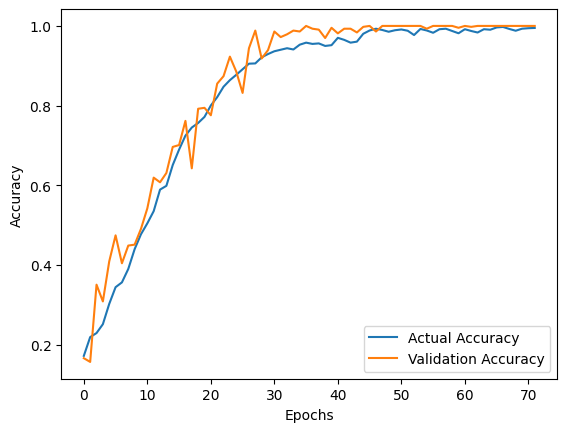

In [ ]:
plt.plot(history.history['accuracy'], label='Actual Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel("Accuracy")

plt.legend()
plt.show()

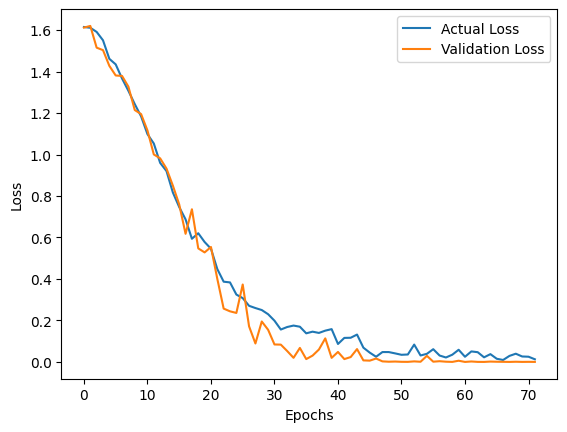

In [ ]:
plt.plot(history.history['loss'], label="Actual Loss")
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel("Loss")

plt.legend()
plt.show()

## Model 4 evaluation

In [ ]:
# ******************* Evaluate ***************************
print(f"\n Evaluating....")

val_probs = model_4.predict(X_val, verbose=0)

# Convert to top 3 predictions
label_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}

top3_indices = np.argsort(val_probs, axis=1)[:, -3:][:, ::-1]

val_predictions = []
for indices in top3_indices:
    val_predictions.append([label_to_letter[i] for i in indices])


map3_score = calculate_map(val_predictions, val_data['answer'].tolist())

print(f"\n Transfer Learning + GRU MAP@3: {map3_score:.4f}\n")


# Store results
# transfer_gru_results['fold_models'].append(model)
# transfer_gru_results['fold_scores'].append(map3_score)
# transfer_gru_results['fold_predictions'].append(val_predictions)



 Evaluating....

 Transfer Learning + GRU MAP@3: 1.0000



In [ ]:
run_4.log({
    "@map_on_val":map3_score
})

run_4.finish()

@map_on_val,▁
@map_on_val,1


## Submission

In [ ]:
# ************ for model 4 ************************
X_test= np.array([
    prepare_text_for_gpu(row, tokenizer, max_length) for _, row in test_df.iterrows()
])

test_props = model_4.predict(X_test, verbose=0)

# Convert to top 3 predictions
label_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}

top3_indices = np.argsort(test_props, axis=1)[:, -3:][:, ::-1]

val_predictions = []
for indices in top3_indices:
    val_predictions.append([label_to_letter[i] for i in indices])

model_4_pred_on_test= [" ".join(lst_idx) for lst_idx in val_predictions]

In [ ]:
# model_3_result
# "prediction":  pred_test_top3

submission_df= pd.DataFrame({
    "id": test_df['id'],
    "prediction":  model_4_pred_on_test
})

In [ ]:
submission_df.to_csv("submission.csv", index=False)

In [ ]:
print(f"@map for first model:{calculate_map(pred_top3_val_data,val_data['answer'].tolist())}")
print(f"@map for second model: {calculate_map(pred_top3_val_data_sec_model,val_data['answer'].tolist())}")
print(f"@map for third model: {calculate_map(model3_result_on_val,val_data['answer'].tolist())}")

NameError: name 'pred_top3_val_data' is not defined

In [ ]:
# calculate_map(val_predictions_model2, val_data['answer'].tolist())

## Save best Model

In [ ]:
model_4.save("../model/model4_0_758.keras")